(control:examples:optimal-control:inverted-pendulum)=
# Inverted pendulum

## Equations of motion with Lagrangian mechanics


### Non-linear equations

Second-order dynamical equation of the mechanical system reads

$$m \ell^2 \ddot{\theta} + c \dot{\theta} = m g \ell \sin \theta + C \ .$$

Equilibrium conditions of unforced system ($C = 0$) are found for $\overline{\theta}_1 = 0$, $\overline{\theta}_2 = \pi$. The first equilibrium is unstable, the second equilibrium is stable. Around the second equilibrium, the linearized equation becomes

$$m \ell^2 \ddot{\theta} + c \dot{\theta} + m g \ell \theta = C \ ,$$

so that, for under-damped systems, it's possible to define the natural frequency of the undamped system $\omega_n^2 = \frac{g}{\ell}$, and the damping coefficient $\xi$


as, by definition

$$2 \xi \omega_n := \frac{c}{m\ell^2} $$

$$\xi = \frac{c}{2 m \ell^2 \omega_n} = \frac{c}{2 m \ell^2 \sqrt{\frac{g}{\ell}}}$$

### Equilibria

### Linearized equations around equilibria

**Linearized equation around the stable equilibrium.** First-order system equation around the stable equilibium becomes

$$\begin{bmatrix} \dot{\theta} \\ \dot{\Omega} \end{bmatrix} = \begin{bmatrix} 0 & 1 \\ - \omega_n^2 & - 2 \omega_n \xi \end{bmatrix} \begin{bmatrix} \theta \\ \Omega \end{bmatrix} + \begin{bmatrix} 0 \\ \frac{1}{m \ell^2} \end{bmatrix} C \ .$$


**Linearized equation around the unstable equilibrium.** First-order system equation around the **unstable equilibium** becomes

$$\begin{aligned}
  \begin{bmatrix} \dot{\theta} \\ \dot{\Omega} \end{bmatrix} & = \begin{bmatrix} 0 & 1 \\ \omega_n^2 & - 2 \omega_n \xi \end{bmatrix} \begin{bmatrix} \theta \\ \Omega \end{bmatrix} + \begin{bmatrix} 0 \\ \frac{1}{m \ell^2} \end{bmatrix} C \\
  y & = \begin{bmatrix} \ 1 & 0 \ \end{bmatrix} \begin{bmatrix} \theta \\ \Omega \end{bmatrix} \ .
\end{aligned}$$

This the equation we're interested in, when studying the inverted pendulum system.

### Augmented sytem for tracking reference signal

Let $\mathbf{y}_{\text{ref}}$ a reference signal. An augmented system can be defined in order to used optimal control. Let

$$\begin{aligned}
 \dot{\mathbf{x}} & = \mathbf{A} \mathbf{x} + \mathbf{B} \mathbf{u} \\
      \mathbf{y}  & = \mathbf{C} \mathbf{x} + \mathbf{D} \mathbf{u}
\end{aligned}$$

the state-space representation of the plant. Let $\mathbf{y}_{\text{ref}}$ a desired output and the integral error

$$\mathbf{e}_{\text{int}}(t) := \int_{\tau=0}^{t} \left\{ \mathbf{y}(\tau) - \mathbf{y}_{\text{ref}}(\tau) \right\} d \tau \ ,$$

as a new state with dynamical equation

$$\dot{\mathbf{e}}_{\text{int}} = \mathbf{y}(t) - \mathbf{y}_{\text{ref}}(t) = \mathbf{C} \mathbf{x} + \mathbf{D} \mathbf{u} - \mathbf{y}_{\text{ref}} \ .$$

The optimal control is applied to the augmented system

$$\underbrace{\begin{bmatrix} \dot{\mathbf{x}} \\ \dot{\mathbf{e}}_{\text{int}} \end{bmatrix}}_{\dot{\mathbf{z}}} = \underbrace{\begin{bmatrix} \mathbf{A} & \cdot \\ \mathbf{C} & \cdot \end{bmatrix}}_{\hat{\mathbf{A}}} \underbrace{\begin{bmatrix} \mathbf{x} \\ \mathbf{e}_{\text{int}} \end{bmatrix}}_{\mathbf{z}} + \underbrace{\begin{bmatrix} \mathbf{B} \\ \mathbf{D} \end{bmatrix}}_{\hat{\mathbf{B}}_u} \mathbf{u} + \underbrace{\begin{bmatrix} \cdot \\ -\mathbf{I} \end{bmatrix}}_{\hat{\mathbf{B}}_{ref}} \mathbf{y}_{ref}$$

$$\mathbf{y} = \hat{\mathbf{C}} \mathbf{z} + \hat{\mathbf{D}}_u \mathbf{u} \ .$$

Optimal control framework provides the opitmal gain matrix $\hat{\mathbf{K}}$, so that $\mathbf{u} = - \hat{\mathbf{K}} \mathbf{z}$ and the closed loop system becomes

$$\begin{aligned}
  \dot{\mathbf{z}} & = \left( \hat{\mathbf{A}} - \hat{\mathbf{B}}_u \hat{\mathbf{K}} \right) \mathbf{z} + \hat{\mathbf{B}}_{ref} \mathbf{y}_{ref} \\
  \mathbf{y} & = \left( \hat{\mathbf{C}} - \hat{\mathbf{D}}_u \mathbf{K} \right) \mathbf{z} \ .
\end{aligned}$$

---

If the output of the system is the angle $\theta(t)$, with reference signal $\mathbf{y}_{\text{ref}} = \theta_{\text{ref}}$, the dynamical system is a SISO system, whose state-space representation is

...


## Libraries

In [3]:
# Install the control library if running in Colab
try:
    import control as ct
except ImportError:
    !python3.11 -m pip install control

import numpy as np
import scipy as sp
import control as ct
import matplotlib.pyplot as plt


In [4]:
print(ct.__version__)


0.10.2


## Plant dynamical equations

In [5]:
#> Inverted pendulum plant (linearized) equations
#> Parameters
"""
omega_n = 1.0
xi = .1

g = 9.81
m = 1.
l = g / omega_n**2
c = 2 * xi * omega_n * m * l**2
"""

g = 9.81
m = .1
l = .2
omega_n = np.sqrt(g/l)

xi = .02
c = 2 * xi * omega_n * m * l**2


#> Matrices of the state-space representation
A = np.array([[0., 1.], [omega_n**2, -xi*omega_n]])
B = np.array([[0.], [1./(m*l**2)]])
C = np.array([[1., 0.]])
D = np.array([[0]])

sys = ct.ss(A, B, C, D)


In [6]:
#> Augmented system for reference input
# dx     = A x + B u
# dz = e =   y[0] - yref = C[0,:] x + D[0,:] u - yref
#  y     =   x
# d [ x ] = [ A      . ][ x ] + [ B     ] u + [ . ] yref
#   [ z ]   [ C[0:]  . ][ z ]   [ D[0:] ]     [-I ]

Aa = np.block([
    [     A, np.zeros((2, 1))],
    [C[0,:], np.zeros((1, 1))]
])
Ba = np.block([
    [B],
    [D[0,:]]
])
Ca = np.block([
    [C, np.zeros((1,1))]
])
Da = np.array([[0]])

sys_aug = ct.ss(Aa, Ba, Ca, Da)

evals = ct.poles(sys_aug)
print(evals)


[ 0.        +0.j -7.07395639+0.j  6.93388498+0.j]


## Control


### Optimal control for full-state feedback

State-space representation of the open-loop system from the tracking error $\mathbf{e}$ to the output $\mathbf{y}$ reads

$$\left\{\begin{aligned}
  \dot{\mathbf{x}} & = \left( \mathbf{A} - \mathbf{B} \mathbf{K}_{\mathbf{x}} \right) \mathbf{x} - \mathbf{B} \mathbf{K}_{\mathbf{e}} \mathbf{e}_{\text{int}} \\
  \dot{\mathbf{e}}_{\text{int}} & = \mathbf{e} \\
  \mathbf{y} & = \left( \mathbf{C} - \mathbf{D} \mathbf{K}_{\mathbf{x}} \right) \mathbf{x} - \mathbf{D} \mathbf{K}_{\mathbf{e}} \mathbf{e}_{\text{int}} \ ,
\end{aligned}\right.$$

or

$$\left\{\begin{aligned}
  \begin{bmatrix} \dot{\mathbf{x}} \\ \dot{\mathbf{e}}_{\text{int}} \end{bmatrix} & = \begin{bmatrix} \mathbf{A} - \mathbf{B} \mathbf{K}_{\mathbf{x}} & - \mathbf{B} \mathbf{K}_{\mathbf{e}} \\ \cdot & \cdot \end{bmatrix} \begin{bmatrix} \mathbf{x} \\ \mathbf{e}_{\text{int}} \end{bmatrix} + \begin{bmatrix} \cdot \\ \mathbf{I} \end{bmatrix} \mathbf{e} \\
  \mathbf{y} & = \begin{bmatrix} \mathbf{C} - \mathbf{D} \mathbf{K}_{\mathbf{x}} & - \mathbf{D} \mathbf{K}_{\mathbf{e}} \end{bmatrix} \begin{bmatrix} \mathbf{x} \\ \mathbf{e}_{\text{int}} \end{bmatrix}
\end{aligned}\right.$$

#### Sensitivity to control weight

For a given weight matrix on the augmented state $\mathbf{Q}$, here the sensitivity to the value of the control weight $\mathbf{R} = [ \ r \ ]$ is investigated. Here, the output is the angle $\theta$ of the inverted pendulum w.r.t. the unstable equilibrium.

Bode and Nyquist diagram of the stabilized[^optimal-L-stabilized] open-loop TF are shown, along with the eigenvalues of the closed loop system, with the reference signal as input.

[^optimal-L-stabilized]: After the optimal control gain matrix $\mathbf{K}$ has been computed, i.e. it's not surprising that this open-loop system is stable.

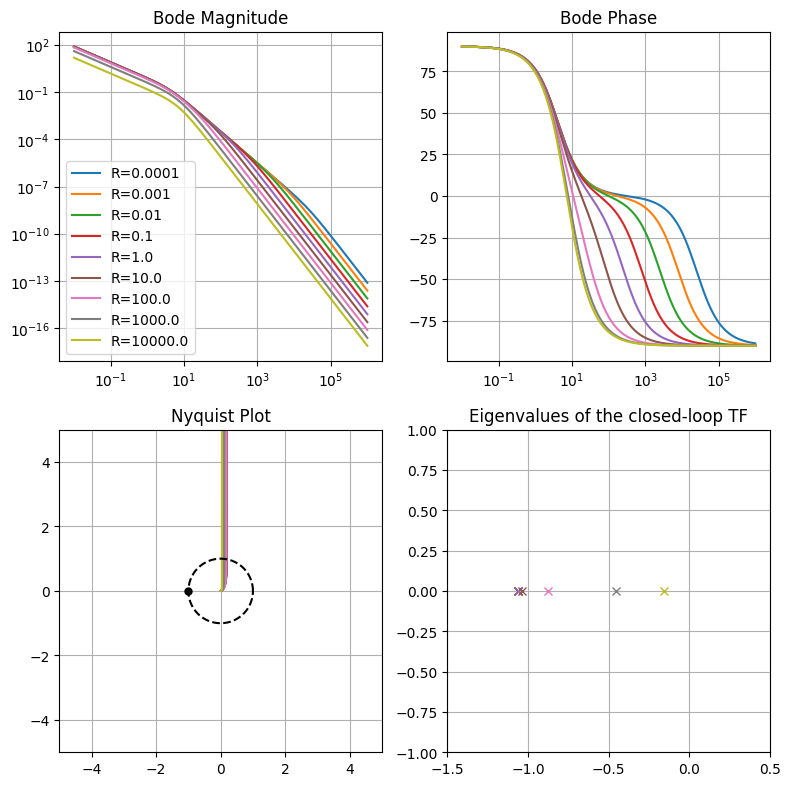

In [10]:
# LQR Weights
Q = np.diag([10, 1, 10]) # Penalize angle error more than angular velocity
# R_values = np.linspace(0.001, .01, 4)  # [0.001, 0.01, 0.1]
R_values = np.logspace(-4, 4, 9)

omega_freq = np.logspace(-2, 6, 500)

fig, ax = plt.subplots(2,2, figsize=(8, 8))

for R in R_values:

    # Compute LQR Gain
    # K, S, E = ct.lqr(A, B, Q, R)
    Ka, Sa, Ea = ct.lqr(sys_aug, Q, R)

    #> Loop transfer function L(s) = K * (sI - A)^-1 * B
    #> Open-loop TF, L(s) = G(s) R(s), with R(s) = K
    # from the error to the output
    A_ol = np.block([
        [     A - B @ Ka[:,:2], - B @ Ka[:,2:]],
        [      np.zeros((1,2)), np.zeros((1, 1))]
    ])
    B_ol = np.block([[.0], [.0], [1.]])
    C_ol = np.block([[ C - D @ Ka[:,:2], - D @ Ka[:,2]]])
    D_ol = np.zeros((1,1))
    sys_ol = ct.ss(A_ol, B_ol, C_ol, D_ol)

    #> Closed-loop TF
    # from the disturbance signal to the output
    # Simulate closed-loop response with reference input
    A_cl = Aa - Ba @ Ka
    B_ref = np.array([[0], [0], [-1]])
    C_cl = np.array([[1, 0, 0]])
    D_cl = np.zeros((1, 1))

    sys_cl = ct.ss(A_cl, B_ref, C_cl, D_cl)

    evals_cl = ct.poles(sys_cl)

    #> Frequency response
    mag_L, phase_L, omega_L = ct.frequency_response(sys_ol, omega_freq)

    #> Plots
    #> Bode plots (first line) of L(s)
    ax[0,0].loglog(omega_L, mag_L, label=f'R={R}')
    ax[0,1].semilogx(omega_L, np.degrees(phase_L), label=f'R={R}')
    #> Nyquist diagram of L(s)
    ax[1,0].plot(mag_L*np.cos(phase_L), mag_L*np.sin(phase_L), label=f'R={R}')
    #> Eigenvalues of the closed-loop system
    ax[1,1].plot(np.real(evals_cl), np.imag(evals_cl), 'x', label=f'R={R}')

#> Critical point and circle in Nyquist plot
theta_v = np.linspace(0, 2*np.pi, 100)
ax[1,0].plot([-1], [0], 'o', ms=5, color="black")
ax[1,0].plot(np.cos(theta_v), np.sin(theta_v), '--', color="black")

#> Formatting plots
ax[0,0].set_title('Bode Magnitude'); ax[0,0].grid(True); ax[0,0].legend()
ax[0,1].set_title('Bode Phase'); ax[0,1].grid(True)
ax[1,0].set_title('Nyquist Plot'); ax[1,0].grid(True); ax[1,0].set_aspect('equal'); ax[1,0].set_xlim([-5, 5]); ax[1,0].set_ylim([-5, 5])
ax[1,1].set_title('Eigenvalues of the closed-loop TF'); ax[1,1].grid(True); ax[1,1].set_aspect('equal')
ax[1,1].set_xlim([-1.5, .5]); ax[1,1].set_ylim([-1., 1.])

fig.set_tight_layout(True)

plt.show()

### Optimal observer

System equations, without disturbances/noise

$$\left\{\begin{aligned}
  \dot{\mathbf{x}} & = \mathbf{A} \mathbf{x} + \mathbf{B} \mathbf{u} \\
  \mathbf{y} & = \mathbf{C} \mathbf{x} + \mathbf{D} \mathbf{u} \ ,
\end{aligned}\right.$$

Observer (state estimator) equations

$$\left\{\begin{aligned}
  \hat{\mathbf{y}} & = \mathbf{C} \hat{\mathbf{x}} + \mathbf{D} \mathbf{u} \\
  \dot{\hat{\mathbf{x}}} & = \mathbf{A} \hat{\mathbf{x}} + \mathbf{B} \mathbf{u} + \mathbf{L} \left( \mathbf{y} - \hat{\mathbf{y}} \right) \\
  & = \left( \mathbf{A} - \mathbf{L} \mathbf{C} \right) \hat{\mathbf{x}} + \mathbf{L} \mathbf{C} \mathbf{x} + \mathbf{B} \mathbf{u} \ ,
\end{aligned}\right.$$

so that the dynamical equation of the error $\boldsymbol\varepsilon := \hat{\mathbf{x}} - \mathbf{x}$ reads

$$\dot{\boldsymbol\varepsilon} = \left( \mathbf{A} - \mathbf{L} \mathbf{C} \right) \boldsymbol\varepsilon \ .$$

The dynamical equations of the augmented system, plant+observer, reads

$$\begin{bmatrix} \dot{\mathbf{x}} \\ \dot{\boldsymbol\varepsilon} \end{bmatrix} = \begin{bmatrix} \mathbf{A} & \mathbf{0} \\ \mathbf{0} & \mathbf{A} - \mathbf{L} \mathbf{C} \end{bmatrix} \begin{bmatrix} \mathbf{x} \\ \boldsymbol\varepsilon \end{bmatrix} +  \begin{bmatrix} \mathbf{B} \\ \mathbf{0} \end{bmatrix} \mathbf{u} \ ,$$

and the observer design here is the design of a matrix $\mathbf{L}$ that makes the dynamics of the error $\boldsymbol\varepsilon$, and thus the matrix $\mathbf{A} - \mathbf{L} \mathbf{C}$, asymptotically stable.

#### State estimator with process and measurement noise

$$\left\{\begin{aligned}
  \dot{\mathbf{x}} & = \mathbf{A} \mathbf{x} + \mathbf{B} \mathbf{u} + \mathbf{B}_d \mathbf{d}\\
  \mathbf{y} & = \mathbf{C} \mathbf{x} + \mathbf{D} \mathbf{u} + \mathbf{D}_d \mathbf{d} + \mathbf{D}_r \mathbf{r} \ ,
\end{aligned}\right.$$

The state estimator problem with $\mathbf{D}_d = \mathbf{0}$ and $\mathbf{D}_\mathbf{r} = \mathbf{I}$ can be solved with the function $\texttt{lqe}$ of the $\texttt{control}$ library,

$$\begin{aligned}
 & \texttt{control.lqe(sys, Edd, Err, Edr)} \\
 & \texttt{control.lqe(A, Bd, C, Edd, Err, Edr)} \\
\end{aligned}$$

In [11]:
#> Optimal state estimator
Edd = np.eye(1) * 0.01       # Process noise covariance
Err = np.array([[0.001]])    # Measurement noise covariance

#> Method 1.
Bd = np.array([[.0], [1.]])  # np.eye(2)
L, P, E = ct.lqe(A, Bd, C, Edd, Err)

print(L)

"""
#> Method 2.
# Use LQR duality: lqe(A, B, C, V, W) is dual to lqr(A.T, C.T, V, W)
# Note: we use C.T because it replaces B in the dual problem
L_transposed, P, E = ct.lqr(A.T, C.T, V, W)

# The actual observer gain is the transpose of the 'feedback' result
L = L_transposed.T
"""

[[13.87503766]
 [96.258335  ]]


"\n#> Method 2.\n# Use LQR duality: lqe(A, B, C, V, W) is dual to lqr(A.T, C.T, V, W)\n# Note: we use C.T because it replaces B in the dual problem\nL_transposed, P, E = ct.lqr(A.T, C.T, V, W)\n\n# The actual observer gain is the transpose of the 'feedback' result\nL = L_transposed.T\n"

### Combination of controller and observer - separation principle

In [12]:
#> Optimal controller
R = 1e-4
Ka, Sa, Ea = ct.lqr(sys_aug, Q, R)

A_cl_obs = np.block([
    [ A - B @ Ka[:,:2], - B @ Ka[:,:2],   - B @ Ka[:,2:]],
    [  np.zeros((2,2)),      A - L @ C, np.zeros((2, 1))],
    [ C - D @ Ka[:,:2], - D @ Ka[:,:2],   - D @ Ka[:,2:]]
])
B_cl_obs = np.block([[np.zeros((2,1))], [np.zeros((2,1))], [-1]])
C_cl_obs = np.block([ C - D @ Ka[:,:2], - D @ Ka[:,:2], - D @ Ka[:,2:]])
D_cl_obs = np.zeros((1, 1))

sys_cl_obs = ct.ss(A_cl_obs, B_cl_obs, C_cl_obs, D_cl_obs)

### Properties of control

...


## Verifying control on non-linear system

### Reference tracking on the non-linear system

Here the control system is tested on the non-linear system for tracking a reference square wave signal.

Non-linear equations of the plant

$$\begin{aligned}
 \dot{\mathbf{x}} & = \mathbf{f}(\mathbf{x}, \mathbf{u}) \\
 \mathbf{y} & = \mathbf{C} \mathbf{x} + \mathbf{D} \mathbf{u}
\end{aligned}$$

Observer

$$\dot{\boldsymbol\varepsilon} = \left( \mathbf{A} - \mathbf{L} \mathbf{C} \right) \boldsymbol\varepsilon$$

Integral error

$$\dot{\mathbf{e}}_{\text{int}} = \mathbf{y} - \mathbf{y}_{\text{ref}}$$

Proportional control

$$\mathbf{u} = - \mathbf{K}_{\mathbf{x}} \mathbf{x} - \mathbf{K}_{\mathbf{x}} \boldsymbol\varepsilon - \mathbf{K}_{\mathbf{e}} \mathbf{e}_{\text{int}} \ .$$


In [27]:
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# solve_ivp(fun, t_span, y0, method="RK45", ..., args=tuple)

# fun(t, z, args=tuple)
def f(t, z, args):
    """
    State, z = [ x, vareps, e_int ]
    """

    #> args is supped to be a 1-element tuple with a dict
    args_di = args

    #> System parameters
    g, l, m, c = args_di["g"], args_di["l"], args_di["m"], args_di["c"]
    om_n = np.sqrt(g/l)
    xi = c / (2 * m * l**2 * om_n)

    #> Linearized system matrices
    A, B, C, D = args_di["A"], args_di["B"], args_di["C"], args_di["D"]

    #> Optimal control matrix
    Kx, Ke = args_di["Kx"], args_di["Ke"]
    #> State-estimator L matrix
    L = args_di["L"]

    #> Reference input: select the proper y_ref for the current time 't'
    y_ref_func = args_di["y_ref_func"]
    yref = y_ref_func(t) # Interpolates to get the value at time t

    #> Motor physical limits
    motor_clipping = args_di["motor_clipping"]
    u_max = args_di["u_max"]

    #> State variables
    th, om, eps, e_int = z[0], z[1], z[2:4], z[4]
    x = z[0:2]

    #> Feed-back control
    u = - Kx @ x - Kx @ eps - Ke @ z[4:]

    if ( motor_clipping ):
        u = np.clip(u, -u_max, u_max)

        #> Need for anti-windup
        # if (u_ideal > u_max and (C @ x + D @ u - yref) > 0) or (u_ideal < -u_max and (C @ x + D @ u - yref) < 0):
        #     de_int = 0 # Stop integrating...
        # else:
        #     de_int = C @ x + D @ u - yref

    dth    = om
    dom    = om_n**2 * np.sin(th) - 2 * om_n * xi * om + u[0] / ( m * l**2 )
    deps   = ( A - L @ C ) @ eps
    de_int = C @ x + D @ u - yref

    return np.concatenate(([dth, dom], deps, de_int))


In [28]:
#> Reference signal
t_span = [0, 80]
t_eval = np.linspace(t_span[0], t_span[1], 200)
y_ref_values = np.where(t_eval%20 < 10, np.radians(0), np.radians(5))

#> Create an interpolator to pass to the solve_ivb function
y_ref_func = interp1d(t_eval, y_ref_values, kind='linear', fill_value="extrapolate")

In [29]:
# 1. Bundle all parameters into the dictionary
sim_config = {
    "g": 9.81, "l": l, "m": m, "c": c,        # Example physical params
    "A": A, "B": B, "C": C,  "D": D,          # Linearized matrices
    "Kx": Ka[:, :2], "Ke": Ka[:, 2:],         # Optimal gains (Kx is 1x2, Ke is 1x1)
    "L": L,                                   # Observer gain
    "y_ref_func": y_ref_func,                 # Ref input interpolator function
    "motor_clipping": True, "u_max": .05      # Motor clippint
}

# 2. Set Initial Conditions [theta, omega, eps_theta, eps_omega, e_int]
# Example: System starts at 2 degrees, observer thinks it's at 0
# Error is defined to be eps = x_hat - x
z0 = [np.radians(2), 0, -np.radians(2), 0, 0]

# 3. Execute the simulation
from scipy.integrate import solve_ivp
sol = solve_ivp(
    f,
    t_span,
    z0,
    args=(sim_config,),
    t_eval=t_eval,
    method='BDF' # Standard Runge-Kutta integrator
)

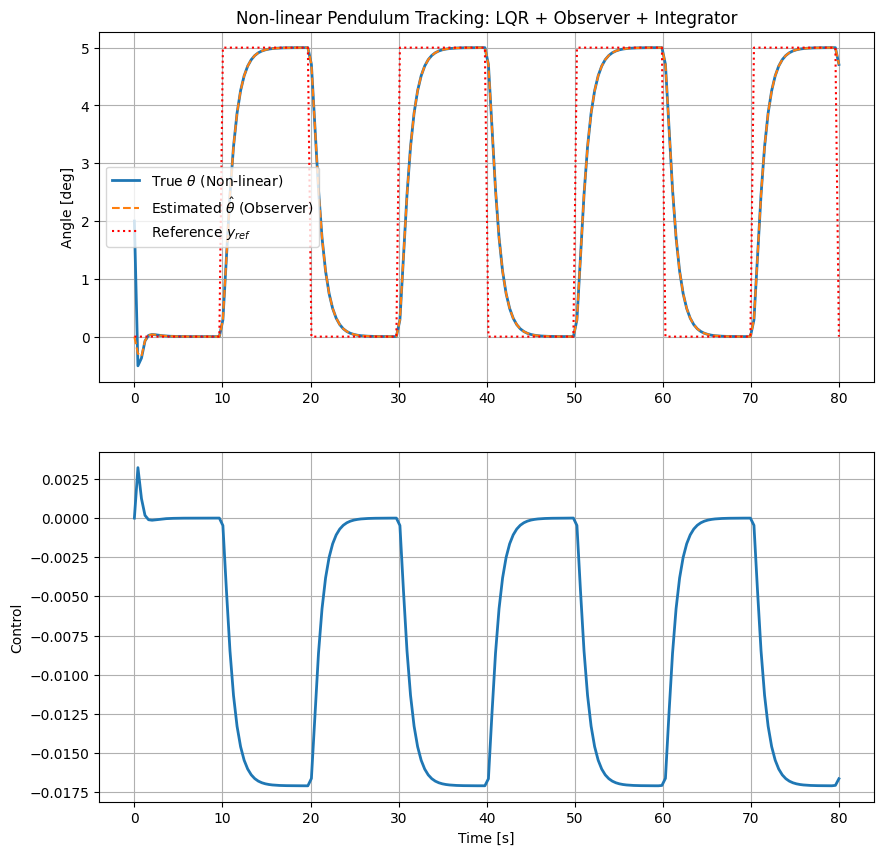

In [26]:
import matplotlib.pyplot as plt

#> Output and control effort
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

#> Estimation error, eps = x_hat - x, x_hat = x + eps
hat_theta = sol.y[0] + sol.y[2]

# Plot True Pendulum Angle (convert back to degrees)
ax[0].plot(sol.t, np.degrees(sol.y[0]), label='True $\\theta$ (Non-linear)', linewidth=2)      # output
ax[0].plot(sol.t, np.degrees(hat_theta), '--', label='Estimated $\\hat{\\theta}$ (Observer)')  # estimated output
ax[0].plot(sol.t, np.degrees(y_ref_func(sol.t)), 'r:', label='Reference $y_{ref}$')            # reference

ax[0].set_title("Non-linear Pendulum Tracking: LQR + Observer + Integrator")
# ax[0].set_xlabel("Time [s]")
ax[0].set_ylabel("Angle [deg]")
ax[0].legend()
ax[0].grid()

u = -Ka[:,:2] @ sol.y[0:2] - Ka[:,:2] @ sol.y[2:4] - Ka[:,2:] @ sol.y[4:]
ax[1].plot(sol.t, u[0], label='True $\\theta$ (Non-linear)', linewidth=2)      # output
ax[1].set_ylabel("Control")
ax[1].set_xlabel("Time [s]")
ax[1].grid(True)

plt.show()

